# 🐒 Global Primates Watch — Análise Geoespacial (Shapefile IUCN)

Notebook com pipeline completo:
- Leitura do shapefile
- Detecção/uso correto de colunas (`order_`, `category`, `sci_name`)
- Filtro de primatas (case-safe)
- Deduplicação por espécie
- Tradução das categorias (PT-BR)
- Agrupamento de risco
- Visualizações com **gradiente consistente de risco**
- Export para GeoJSON/CSV


In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

## 📥 Carregar Shapefile

In [2]:
# Ajuste o caminho se necessário
path = 'MAMMALS_TERRESTRIAL_ONLY.shp'

gdf = gpd.read_file(path)
print('Linhas:', len(gdf))
print('Colunas:', list(gdf.columns))
gdf.head()

Linhas: 12703
Colunas: ['id_no', 'sci_name', 'presence', 'origin', 'seasonal', 'compiler', 'yrcompiled', 'citation', 'subspecies', 'subpop', 'source', 'island', 'tax_comm', 'dist_comm', 'generalisd', 'legend', 'kingdom', 'phylum', 'class', 'order_', 'family', 'genus', 'category', 'marine', 'terrestria', 'freshwater', 'SHAPE_Leng', 'SHAPE_Area', 'geometry']


,id_no,sci_name,presence,origin,seasonal,compiler,yrcompiled,citation,subspecies,subpop,...,order_,family,genus,category,marine,terrestria,freshwater,SHAPE_Leng,SHAPE_Area,geometry
0,18,Abrocoma boliviensis,1,1,1,IUCN SSC Small Mammal Specialist Group,2016,IUCN SSC Small Mammal Specialist Group,NaN,NaN,...,RODENTIA,ABROCOMIDAE,Abrocoma,CR,false,true,false,0.305150,0.005520,"POLYGON ((-64.46864 -17.88625, -64.45733 -17.8..."
1,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,0.497459,0.009368,"POLYGON ((125.426 2.74894, 125.4247 2.74344, 1..."
2,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,1.224802,0.046804,"POLYGON ((125.9087 -1.97096, 125.9154 -1.97336..."
3,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,1.453910,0.045252,"POLYGON ((125.45 3.74304, 125.4545 3.74164, 12..."
4,137,Acerodon celebensis,1,1,1,IUCN,2022,IUCN (International Union for Conservation of ...,NaN,NaN,...,CHIROPTERA,PTEROPODIDAE,Acerodon,VU,false,true,false,2.674807,0.096459,"POLYGON ((125.4067 -1.77926, 125.4054 -1.78686..."


## 🔍 Detectar colunas automaticamente (robusto)

In [3]:
# Detectar nomes prováveis de colunas
def find_col(cols, keywords):
    for c in cols:
        lc = c.lower()
        if any(k in lc for k in keywords):
            return c
    return None

order_col = find_col(gdf.columns, ['order']) or 'order_'
cat_col = find_col(gdf.columns, ['category', 'cat']) or 'category'
name_col = find_col(gdf.columns, ['sci_name', 'binomial', 'name']) or 'sci_name'

print('order_col:', order_col)
print('cat_col:', cat_col)
print('name_col:', name_col)


order_col: order_
cat_col: category
name_col: sci_name


## 🧹 Normalizar textos

In [4]:
gdf[order_col] = gdf[order_col].astype(str).str.upper()
gdf[cat_col] = gdf[cat_col].astype(str).str.upper()
gdf[name_col] = gdf[name_col].astype(str)


## 🐒 Filtrar Primatas

In [5]:
primates = gdf[gdf[order_col] == 'PRIMATES'].copy()
print('Registros (polígonos):', len(primates))
primates.head()

Registros (polígonos): 922


,id_no,sci_name,presence,origin,seasonal,compiler,yrcompiled,citation,subspecies,subpop,...,order_,family,genus,category,marine,terrestria,freshwater,SHAPE_Leng,SHAPE_Area,geometry
159,865,Allenopithecus nigroviridis,1,1,1,IUCN,2019,IUCN (International Union for Conservation of ...,NaN,NaN,...,PRIMATES,CERCOPITHECIDAE,Allenopithecus,LC,false,true,false,159.163290,13.437416,"MULTIPOLYGON (((23.65611 1.11823, 23.66016 1.1..."
160,865,Allenopithecus nigroviridis,3,1,1,IUCN,2019,IUCN (International Union for Conservation of ...,NaN,NaN,...,PRIMATES,CERCOPITHECIDAE,Allenopithecus,LC,false,true,false,140.015634,29.362246,"MULTIPOLYGON (((18.29757 0.41846, 18.30913 0.4..."
161,868,Allocebus trichotis,1,1,1,IUCN,2020,IUCN (International Union for Conservation of ...,NaN,NaN,...,PRIMATES,CHEIROGALEIDAE,Allocebus,EN,false,true,false,13.473550,0.617540,"MULTIPOLYGON (((48.39198 -19.05038, 48.38841 -..."
163,914,Alouatta pigra,1,1,1,IUCN,2020,IUCN (International Union for Conservation of ...,NaN,NaN,...,PRIMATES,ATELIDAE,Alouatta,EN,false,true,false,61.335690,21.055203,"MULTIPOLYGON (((-87.87473 18.2655, -87.87526 1..."
164,918,Alouatta ululata,1,1,1,IUCN,2008,IUCN (International Union for Conservation of ...,NaN,NaN,...,PRIMATES,ATELIDAE,Alouatta,EN,false,true,false,18.753006,8.096018,"MULTIPOLYGON (((-39.48092 -3.12769, -39.48104 ..."


## 📊 Espécies únicas (sem duplicar áreas)

In [6]:
species = primates[[name_col, cat_col]].drop_duplicates().rename(columns={name_col: 'sci_name', cat_col: 'category'})
print('Espécies únicas:', species['sci_name'].nunique())
species.head()

Espécies únicas: 526


,sci_name,category
159,Allenopithecus nigroviridis,LC
161,Allocebus trichotis,EN
163,Alouatta pigra,EN
164,Alouatta ululata,EN
165,Alouatta juara,LC


## 🌐 Tradução e agrupamento de risco

In [7]:
traducao = {
    'CR': 'Criticamente Ameaçado',
    'EN': 'Em Perigo',
    'VU': 'Vulnerável',
    'NT': 'Quase Ameaçado',
    'LC': 'Pouco Preocupante',
    'DD': 'Dados Insuficientes',
    'EX': 'Extinto'
}

species['category_pt'] = species['category'].map(traducao)

risk_map = {
    'CR': 'Alto Risco',
    'EN': 'Alto Risco',
    'VU': 'Alto Risco',
    'NT': 'Médio Risco',
    'LC': 'Baixo Risco',
    'DD': 'Desconhecido',
    'EX': 'Extinto'
}
species['risco'] = species['category'].map(risk_map)

species.head()

,sci_name,category,category_pt,risco
159,Allenopithecus nigroviridis,LC,Pouco Preocupante,Baixo Risco
161,Allocebus trichotis,EN,Em Perigo,Alto Risco
163,Alouatta pigra,EN,Em Perigo,Alto Risco
164,Alouatta ululata,EN,Em Perigo,Alto Risco
165,Alouatta juara,LC,Pouco Preocupante,Baixo Risco


## 🎚️ Ordem correta das categorias (gradual)

In [8]:
# Ordem do menor → maior risco (com DD e EX posicionados ao final)
order_categories = ['LC', 'NT', 'VU', 'EN', 'CR', 'DD', 'EX']
species['category'] = pd.Categorical(species['category'], categories=order_categories, ordered=True)

# Versão em PT também ordenada
order_pt = [traducao.get(c) for c in order_categories]
species['category_pt'] = pd.Categorical(species['category_pt'], categories=order_pt, ordered=True)

species.sort_values('category').head()

,sci_name,category,category_pt,risco
159,Allenopithecus nigroviridis,LC,Pouco Preocupante,Baixo Risco
9477,Saguinus mystax,LC,Pouco Preocupante,Baixo Risco
9493,Saimiri boliviensis,LC,Pouco Preocupante,Baixo Risco
9496,Aotus azarae,LC,Pouco Preocupante,Baixo Risco
9500,Aotus nigriceps,LC,Pouco Preocupante,Baixo Risco


## 📊 Gráfico (ordenado por risco)

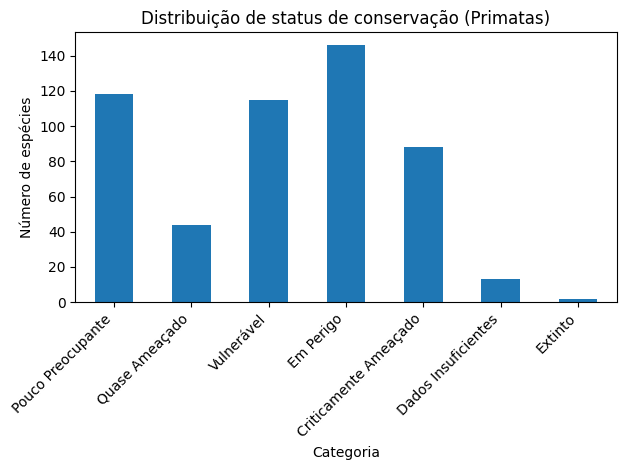

In [9]:
counts = species['category_pt'].value_counts().sort_index()
counts.plot(kind='bar')
plt.title('Distribuição de status de conservação (Primatas)')
plt.xlabel('Categoria')
plt.ylabel('Número de espécies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 🗺️ Mapa com gradiente de risco consistente

In [10]:
# garantir CRS correto (lat/lon)
plot_df = primates.to_crs(epsg=4326)
plot_df["geometry"] = plot_df["geometry"].simplify(0.1)

fig = px.choropleth_map(
    plot_df,
    geojson=plot_df.geometry,
    locations=plot_df.index,
    color=cat_col,

    # ordem correta (gradual)
    category_orders={
        cat_col: ["LC", "NT", "VU", "EN", "CR", "DD", "EX"]
    },

    # cores coerentes
    color_discrete_map={
        "LC": "#2ecc71",   # verde
        "NT": "#a3e635",
        "VU": "#f1c40f",
        "EN": "#e67e22",
        "CR": "#e74c3c",   # vermelho
        "DD": "#95a5a6",
        "EX": "#2c3e50"
    },

    center={"lat": 0, "lon": 0},
    zoom=1,
    opacity=0.6
)

fig.update_layout(
    margin={"r":0,"t":0,"l":0,"b":0}
)

fig.show()

## 💾 Exportar resultados

In [11]:
Path('data').mkdir(exist_ok=True)
species.to_csv('data/primates_species_clean.csv', index=False)
primates.to_file('data/primates_map.geojson', driver='GeoJSON')
print('Arquivos exportados em /data')

Arquivos exportados em /data
